In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

# Load data
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# Build autoencoder
input_dim = 784
latent_dim = 32

encoder_input = layers.Input(shape=(input_dim,))
encoded = layers.Dense(128, activation="relu")(encoder_input)
encoded = layers.Dense(latent_dim, activation="relu")(encoded)

decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(input_dim, activation="sigmoid")(decoded)


autoencoder_bce = models.Model(encoder_input , decoded)
autoencoder_bce.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder_bce.fit(x_train, x_train, epochs=5, batch_size=256,
                     shuffle=True, validation_data=(x_test, x_test))



Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3701 - val_loss: 0.3153
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3046 - val_loss: 0.3007
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2959 - val_loss: 0.2951
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2913 - val_loss: 0.2915
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2882 - val_loss: 0.2894


In [4]:
reconstructed_bce = autoencoder_bce.predict(x_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


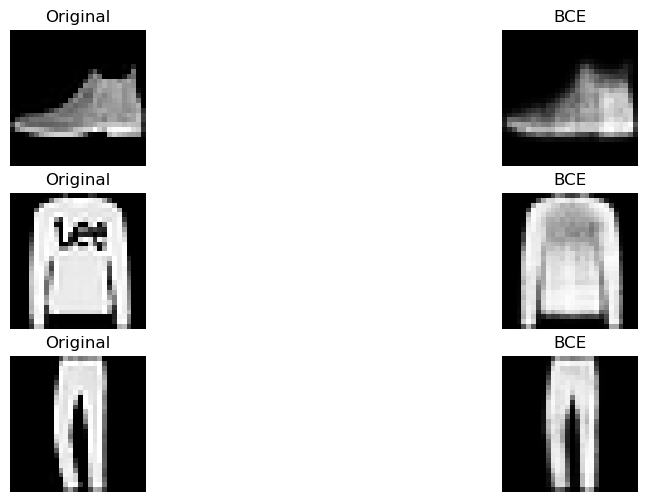

In [6]:


plt.figure(figsize=(9, 6))
for i in range(3):
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(reconstructed_bce[i].reshape(28, 28), cmap="gray")
    plt.title("BCE")
    plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


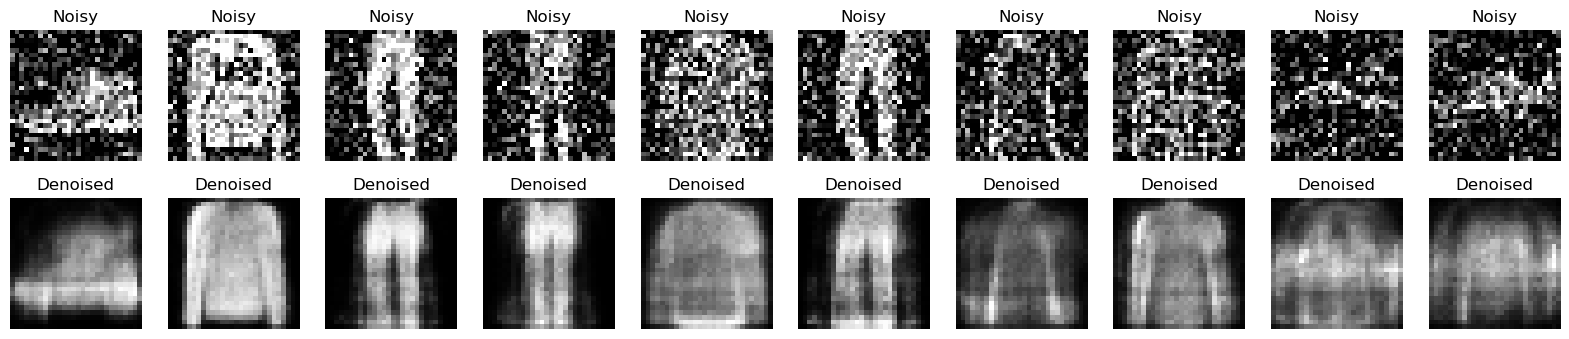

In [10]:
#TASK 3 

noise_factor = 0.4
x_test_noisy = x_test[:10] + noise_factor * np.random.normal(size=x_test[:10].shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


denoised = autoencoder_bce.predict(x_test_noisy)

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(denoised[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")
plt.show()